<a href="https://colab.research.google.com/github/yaduvanshiabhishek/Machine-learning/blob/main/Prac4_Extra_ShoebSheikh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shoeb Sheikh CS23074

Lab 4 Extra Practical: To implement a Decision Tree regression model on the Developer Performance dataset and analyze how different tree depths and splitting criteria influence model performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/ML_Classes/Developer_Performance_dataset_1000.csv"
df = pd.read_csv(path)
df.head()


,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [ ]:
df = df.dropna()

In [ ]:
X = df.drop("Task_Success_Rate", axis=1)
y = df["Task_Success_Rate"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
depths = [2, 4, 6, 8, 10]
results = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([depth, mse, r2])

    print(f"Depth: {depth}")
    print("MSE:", mse)
    print("R2 Score:", r2)
    print("-" * 40)


Depth: 2
MSE: 69.8702023562685
R2 Score: 0.8275243775547128
----------------------------------------
Depth: 4
MSE: 36.861638014397876
R2 Score: 0.9090065042538732
----------------------------------------
Depth: 6
MSE: 32.98342853712783
R2 Score: 0.9185799214046445
----------------------------------------
Depth: 8
MSE: 44.94192094074389
R2 Score: 0.8890602069732483
----------------------------------------
Depth: 10
MSE: 48.93244668642102
R2 Score: 0.8792095354615197
----------------------------------------


In [ ]:
criteria = ["squared_error", "absolute_error"]
criterion_results = []

for crit in criteria:
    model = DecisionTreeRegressor(
        max_depth=6,
        criterion=crit,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    criterion_results.append([crit, mse, r2])

    print(f"Criterion: {crit}")
    print("MSE:", mse)
    print("R2 Score:", r2)
    print("-" * 40)

Criterion: squared_error
MSE: 32.98342853712783
R2 Score: 0.9185799214046445
----------------------------------------
Criterion: absolute_error
MSE: 40.6925
R2 Score: 0.8995499650828594
----------------------------------------


In [ ]:
results_df = pd.DataFrame(results, columns=["Depth", "MSE", "R2"])

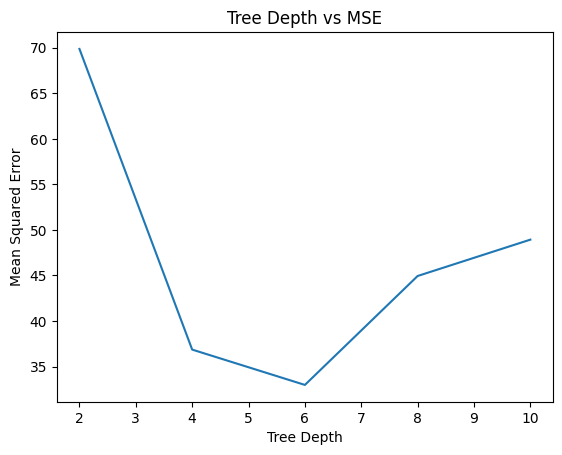

In [ ]:
plt.figure()
plt.plot(results_df["Depth"], results_df["MSE"])
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.title("Tree Depth vs MSE")
plt.show()

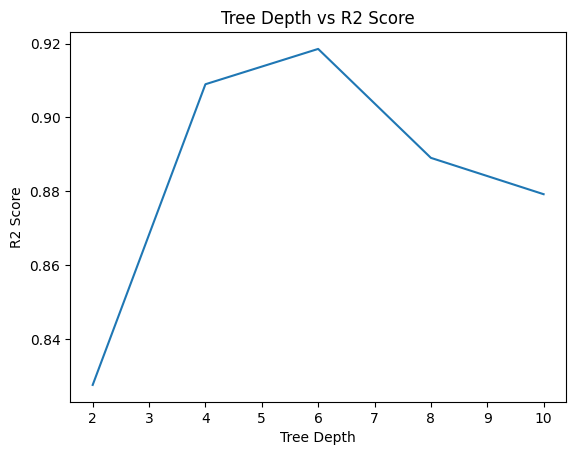

In [ ]:
plt.figure()
plt.plot(results_df["Depth"], results_df["R2"])
plt.xlabel("Tree Depth")
plt.ylabel("R2 Score")
plt.title("Tree Depth vs R2 Score")
plt.show()